# 第三部分 3.1：神经网络基础

| 章节 | 内容 |
|------|------|
| **3.1 神经网络基础** | 感知机、神经元、激活函数、全连接神经网络（MLP）|
| **3.2 训练原理** | 损失函数、梯度下降、反向传播、PyTorch 自动微分、优化器变体（SGD / Adam）|
| **3.3 正则化与调参** | Dropout、BatchNorm、学习率调度、早停 |

---

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print('环境就绪，PyTorch 版本：', torch.__version__)

环境就绪，PyTorch 版本： 2.12.0+cpu


## 3.1 神经网络基础

### 感知机（Perceptron）

**感知机**是 1957 年 Rosenblatt 提出的最早的人工神经网络模型，灵感来自生物神经元。它的结构很简单：

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

$$\hat{y} = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{if } z < 0 \end{cases}$$

激活函数是**阶跃函数（Step Function）**，输出只有 **0 或 1**，只能做**二分类**。

感知机的训练规则也很简单：预测正确则不更新，预测错误则把权重向正确方向推一步（感知机学习算法）。不需要损失函数，也不需要梯度下降。

**感知机的根本局限**：
- 决策边界是一条直线（线性超平面），只能处理**线性可分**问题
- 对于 XOR 这类最简单的非线性问题，无论怎么调权重都无法正确分类
- 1969 年 Minsky 和 Papert 从数学上证明了这一点，直接导致第一次「AI 寒冬」

**神经网络如何突破这一限制？**

核心思路是**堆叠多层神经元**，在输入和输出之间加入隐藏层。每一层先对数据做一次变换，把原始空间中线性不可分的点重新排列到一个新空间里，再在新空间中画一条直线做分类。映射回原始空间，这条"直线"就变成了弯曲的决策边界。

以 XOR 为例：原始空间中 (0,1) 和 (1,0) 分散在对角位置，无法被直线分开。经过一个只有 2 个神经元的隐藏层变换后，这两个点在新坐标系里**完全重叠**，此时输出层只需画一条直线就能正确分类所有点。

但这里有一个关键条件：**隐藏层的激活函数必须是非线性的**。如果每层都是纯线性变换，无论堆叠多少层，整体仍然等价于一个线性变换，决策边界还是直线。正是 ReLU、Sigmoid 这类非线性激活函数，才让隐藏层的"空间变换"真正产生弯折效果。

> 总结：突破线性限制靠的是**隐藏层 + 非线性激活函数**的组合，缺一不可。

---

### 从感知机到现代神经元

感知机的阶跃函数有两个致命问题：
1. **不可微**：无法用梯度下降训练，必须用那套简单但局限的感知机学习算法
2. **输出非连续**：0/1 输出之间没有「置信度」，无法表达「我有 80% 把握」

解决方案：把阶跃函数**替换为可微的连续激活函数**，让输出从离散的 0/1 变成连续值。这样的单元通常叫**神经元（Neuron）**，是现代深度学习的基本单元：

$$z = \mathbf{w}^\top \mathbf{x} + b$$

$$\hat{y} = f(z)$$

其中 $f$ 是**激活函数**，可以是 Sigmoid、ReLU 等任意可微函数。现在可以对损失函数求导，用梯度下降训练了。

> 感知机 → 神经元：结构完全相同，区别只在激活函数。感知机是神经元的历史原型，但两者的训练方式和能力不同。
>
> 顺便提一下：用 Sigmoid 激活 + 交叉熵损失训练的单个神经元，就等价于**逻辑回归**。

---

### 激活函数

激活函数的作用：给网络引入非线性，使其能拟合任意复杂函数。

| 激活函数 | 公式 | 输出范围 | 主要特点 |
|---------|------|---------|----------|
| **Sigmoid** | $\frac{1}{1+e^{-z}}$ | (0, 1) | 输出可解释为概率；缺点：梯度饱和、梯度消失 |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | (-1, 1) | 零中心化，比 Sigmoid 收敛快；仍有梯度饱和 |
| **ReLU** | $\max(0, z)$ | [0, +∞) | 计算极快；正区间无梯度饱和；负区间梯度为 0（Dead ReLU 问题）|
| **Leaky ReLU** | $\max(0.01z, z)$ | (-∞, +∞) | 修复 Dead ReLU，负区间有小梯度 |
| **GELU** | $z \cdot \Phi(z)$ | 近似 ReLU | Transformer 常用，平滑版 ReLU |

**实践建议**：
- **隐藏层**：优先用 **ReLU**（默认）或 Leaky ReLU；避免用 Sigmoid / Tanh，梯度饱和会拖慢训练
- **输出层**：二分类用 Sigmoid，多分类用 Softmax，回归不加激活函数
- Sigmoid / Tanh 在隐藏层的例外场合：RNN 的门控单元（LSTM / GRU），这些结构需要输出有界的激活值

---

### 全连接神经网络（MLP）

把多个神经元排成若干层，每层每个神经元与上一层**所有**神经元相连，就是**全连接神经网络（Fully Connected Network）**，也叫**多层感知机（Multi-Layer Perceptron，MLP）**。两个名字指的是同一件事：全连接强调结构，MLP 强调它是感知机的多层扩展。

**三类层的分工**：

| 层 | 作用 | 神经元数 |
|----|------|---------|
| **输入层** | 接收原始特征，不做计算 | = 特征维度 |
| **隐藏层** | 对输入做非线性变换，可以堆叠多层 | 超参数（16 / 64 / 256 …）|
| **输出层** | 输出预测结果 | 分类 = 类别数；回归 = 1 |

每层的计算就是神经元公式的矩阵形式，输入 $\mathbf{h}^{(l-1)}$，输出 $\mathbf{h}^{(l)}$：

$$\mathbf{h}^{(l)} = f\!\left(W^{(l)}\,\mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

**"全连接"的含义**：若第 $l-1$ 层有 $m$ 个神经元，第 $l$ 层有 $n$ 个，两层之间就有 $m \times n$ 个权重参数。参数量随输入规模快速增长——这正是后面 CNN 部分讨论"为什么不用 MLP 处理图像"时的出发点。

```
输入层(2)    隐藏层(4)    输出层(1)

  x1 ──┬──── h1 ──┐
       ├──── h2 ──┤
  x2 ──┼──── h3 ──┤──── y
       └──── h4 ──┘

  每个输入节点都连到每个隐藏神经元（全连接）
```

在 PyTorch 里，全连接层对应 `nn.Linear`，一个 MLP 就是若干个 `nn.Linear + 激活函数` 的堆叠。

---

> 以上介绍了神经网络的**结构**——神经元长什么样、激活函数做什么、MLP 如何把神经元组织成网络。  
> **网络如何通过数据学习参数**（损失函数、梯度下降、反向传播）在 3.2 节详细介绍。

In [5]:
import torch
import torch.nn as nn

# ── MLP 结构演示 ────────────────────────────────────────────────
# 任务：2 维输入 → 二分类输出
# 结构：输入层(2) → 隐藏层(16) → 隐藏层(8) → 输出层(1)

mlp = nn.Sequential(
    nn.Linear(2, 16),   # 全连接：2×16 = 32 个权重 + 16 个偏置
    nn.ReLU(),
    nn.Linear(16, 8),   # 全连接：16×8 = 128 个权重 + 8 个偏置
    nn.ReLU(),
    nn.Linear(8, 1),    # 全连接：8×1 = 8 个权重 + 1 个偏置
    nn.Sigmoid(),       # 输出层：二分类用 Sigmoid，输出"是正类的概率"
)

print("MLP 结构：")
print(mlp)

# 统计各层参数量
print("\n各层参数量：")
total = 0
for name, param in mlp.named_parameters():
    n = param.numel()
    total += n
    print(f"  {name:<20} shape={str(list(param.shape)):<15} params={n}")
print(f"  {'总参数量':<20} {'':15} {total}")

# 走一次前向传播，看形状变化
x = torch.randn(4, 2)   # 4 个样本，每个 2 维
print(f"\n前向传播：输入形状 {tuple(x.shape)}")
for i, layer in enumerate(mlp):
    x = layer(x)
    print(f"  第{i+1}层 {type(layer).__name__:<12} 输出形状 {tuple(x.shape)}")

MLP 结构：
Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)

各层参数量：
  0.weight             shape=[16, 2]         params=32
  0.bias               shape=[16]            params=16
  2.weight             shape=[8, 16]         params=128
  2.bias               shape=[8]             params=8
  4.weight             shape=[1, 8]          params=8
  4.bias               shape=[1]             params=1
  总参数量                                 193

前向传播：输入形状 (4, 2)
  第1层 Linear       输出形状 (4, 16)
  第2层 ReLU         输出形状 (4, 16)
  第3层 Linear       输出形状 (4, 8)
  第4层 ReLU         输出形状 (4, 8)
  第5层 Linear       输出形状 (4, 1)
  第6层 Sigmoid      输出形状 (4, 1)


## 3.2 训练原理

### 损失函数（Loss Function）

损失函数衡量模型预测值与真实值之间的差距，是训练的优化目标——训练的本质就是不断调整权重让损失尽可能小。

**回归任务**

均方误差（MSE）是最常用的回归损失，对大误差惩罚更重（误差平方放大了大偏差的影响）：

$$\mathcal{L}_{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

平均绝对误差（MAE）对异常值更鲁棒，但在 0 点不可微：

$$\mathcal{L}_{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**分类任务**

二元交叉熵（BCE）用于二分类，配合 Sigmoid 输出层使用：

$$\mathcal{L}_{BCE} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]$$

交叉熵（Cross-Entropy）用于多分类，配合 Softmax 输出层使用：

$$\mathcal{L}_{CE} = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik} \log \hat{y}_{ik}$$

**为什么分类不用 MSE？**

MSE 用于分类时，损失曲面会出现大量平坦区域，梯度接近 0，导致训练极慢甚至停滞。交叉熵的梯度在预测错误时始终较大，能给出稳定的更新信号。

| 任务 | 输出层激活 | 损失函数 |
|------|-----------|---------|
| 回归 | 无 | MSE / MAE |
| 二分类 | Sigmoid | BCE |
| 多分类 | Softmax | Cross-Entropy |

---

### 梯度与梯度下降

**梯度是什么？**

梯度是损失函数对某个权重的偏导数，直观理解就是：**如果把这个权重稍微增大一点，损失会往哪个方向变、变多快**。

- 梯度为正：增大权重会让损失增大，所以要减小这个权重
- 梯度为负：增大权重会让损失减小，所以要增大这个权重
- 梯度为 0：当前位置是极值点，权重暂时不需要更新

对于有多个权重的网络，梯度是一个向量，每个分量对应一个权重的偏导数，整体指向损失上升最快的方向。

**梯度下降做什么？**

沿梯度的**反方向**更新权重，让损失一步步减小：

$$W \leftarrow W - \eta \cdot \frac{\partial \mathcal{L}}{\partial W}$$

其中 $\eta$ 是**学习率**，控制每步移动的幅度。
- $\eta$ 太大：步子迈太大，在极值附近来回震荡，无法收敛
- $\eta$ 太小：收敛极慢，容易困在局部极值

反向传播（Backpropagation）负责高效地计算每一层、每个权重的梯度，见下一节。

---

### 梯度饱和与梯度消失（Gradient Saturation / Vanishing Gradient）

Sigmoid 和 Tanh 在输入绝对值很大时，曲线趋于平坦，导数趋近于 0，这就是**梯度饱和**。

在深层网络的反向传播中，梯度通过链式法则逐层相乘。如果每层都经过 Sigmoid，每层的梯度都远小于 1，多层连乘后梯度指数级缩小，**靠近输入端的层几乎得不到任何更新信号**，这就是**梯度消失**。

```
输出层梯度：0.25
第 3 层梯度：0.25 × 0.25 = 0.06
第 2 层梯度：0.06 × 0.25 = 0.015
第 1 层梯度：0.015 × 0.25 ≈ 0.004  ← 几乎为 0，权重停止更新
```

ReLU 的解决思路：正区间导数恒为 1，梯度不会因为层数增加而衰减。

---

### 梯度爆炸（Gradient Explosion）

梯度消失的反面问题。如果每层的梯度都大于 1，多层连乘后梯度指数级增大，权重更新幅度失控，训练过程直接发散（Loss 变成 NaN）。

梯度爆炸在**深层网络**和 **RNN** 中尤为常见，常见解决方法：
- **梯度裁剪（Gradient Clipping）**：设定一个阈值，超过阈值则按比例缩小梯度
- **权重初始化**：合理的初始化（如 He 初始化）让各层梯度在初始阶段保持合理范围
- **BatchNorm**：归一化每层的激活值，间接稳定梯度幅度

---

### 前向传播（Forward Pass）

数据从输入层依次通过每一层，每层计算 $\mathbf{h} = f(W\mathbf{x} + \mathbf{b})$，最终得到预测值 $\hat{y}$，再用损失函数计算与真实值的差距。

---

### 反向传播（Backpropagation）

反向传播是**自动微分（Automatic Differentiation）** 的一种实现，利用链式法则从输出层向输入层逐层计算梯度：

$$\frac{\partial \mathcal{L}}{\partial W_l} = \frac{\partial \mathcal{L}}{\partial \mathbf{h}_l} \cdot \frac{\partial \mathbf{h}_l}{\partial W_l}$$

**关键直觉**：不是直接计算「损失对每个权重的影响」，而是把梯度像水流一样从输出端往回传，每层只需知道「从我这里往后传来了多少梯度」以及「我这一层的局部导数」，两者相乘就得到本层权重的梯度。

PyTorch 通过构建**计算图（Computational Graph）** 自动完成这个过程：前向传播时记录所有操作，调用 `.backward()` 时沿图反向计算所有梯度。

---

### 梯度下降变体

得到梯度后，用梯度下降更新权重：

$$W \leftarrow W - \eta \cdot \frac{\partial \mathcal{L}}{\partial W}$$

其中 $\eta$ 是**学习率（Learning Rate）**，控制每步移动的距离。

| 优化器 | 核心思路 | 特点 |
|--------|----------|------|
| **SGD** | 随机取一个 batch 估计全局梯度 | 简单，需要仔细调学习率；可加动量（Momentum） |
| **AdaGrad** | 对频繁更新的参数降低学习率 | 稀疏特征好用；学习率单调递减，后期可能停止更新 |
| **RMSProp** | 梯度平方的指数移动平均，修复 AdaGrad 的递减问题 | LSTM 等循环网络常用 |
| **Adam** | 结合动量（一阶矩）+ RMSProp（二阶矩），自适应学习率 | **实践默认首选**，收敛快，对大多数问题效果好 |

**Batch 策略**：
- **Full-batch GD**：用全部数据计算梯度，准确但慢，内存占用大
- **SGD（随机梯度下降）**：每次只用 1 个样本，噪声大，但更新频繁
- **Mini-batch GD**：每次用一个小批量（32/64/128 个样本）——实践中最常用，在速度和准确性之间取得平衡

> **实践建议**：直接从 Adam + 学习率 1e-3 开始，没有明显问题就不要换优化器。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 场景：训练一个单神经元做二分类
# 网络结构：z = w1·x1 + w2·x2 + b，  ŷ = sigmoid(z)
# 损失函数：BCE（二元交叉熵）
# 梯度推导：全部手动完成，不依赖任何框架

# ── 4 个训练样本 ─────────────────────────────────────────────────
X = np.array([[ 1.0,  0.5],   # 正类：第一象限
              [ 0.8,  1.0],   # 正类
              [-1.0, -0.5],   # 负类：第三象限
              [-0.5, -1.0]])  # 负类
y = np.array([1.0, 1.0, 0.0, 0.0])

# ── 初始参数（故意设成一个错误状态，让模型从错误中学习） ──────────
# 初始决策边界：0.5·x1 - 0.5·x2 = 0 → x2 = x1（对角线），会误分类两个样本
w1, w2, b = 0.5, -0.5, 0.0
lr = 0.5

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

w1_init, w2_init, b_init = w1, w2, b   # 保存初始值，用于可视化对比
history = []

print("梯度下降过程（纯 Python：单神经元 + Sigmoid + BCE）")
print(f"{'步骤':>4}  {'w1':>8}  {'w2':>8}  {'b':>8}  {'loss':>10}")
print("-" * 50)

for step in range(30):

    # ── 第1步：前向传播 ─────────────────────────────────────────
    z     = w1 * X[:, 0] + w2 * X[:, 1] + b  # 线性变换，shape (4,)
    y_hat = sigmoid(z)                         # 激活，输出"是正类的概率"

    # ── 第2步：计算 BCE 损失 ─────────────────────────────────────
    # L = -(1/N) Σ [ y·log(ŷ) + (1-y)·log(1-ŷ) ]
    loss = -np.mean(y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9))

    # ── 第3步：反向传播——链式法则逐步推导 ───────────────────────
    # 梯度沿 L → ŷ → z → (w1, w2, b) 这条链路往回传：
    #
    #   ∂L/∂ŷ = -y/ŷ + (1-y)/(1-ŷ)            [BCE 对 ŷ 求导]
    #   ∂ŷ/∂z = ŷ·(1-ŷ)                        [sigmoid 导数]
    #   ∂L/∂z = ∂L/∂ŷ · ∂ŷ/∂z = ŷ - y         [两式相乘化简]
    dz = y_hat - y                              # 误差信号，shape (4,)

    # z = w1·x1 + w2·x2 + b，对各参数求偏导再乘以 dz：
    #   ∂L/∂w1 = (1/N) Σ dz · x1
    #   ∂L/∂w2 = (1/N) Σ dz · x2
    #   ∂L/∂b  = (1/N) Σ dz
    dw1 = np.mean(dz * X[:, 0])
    dw2 = np.mean(dz * X[:, 1])
    db  = np.mean(dz)

    history.append((w1, w2, b, float(loss)))

    # ── 第4步：更新参数 ─────────────────────────────────────────
    w1 -= lr * dw1
    w2 -= lr * dw2
    b  -= lr * db

    if step < 5 or step == 29:
        marker = " ← 收敛" if step == 29 else ""
        print(f"{step+1:>4}  {w1:>8.4f}  {w2:>8.4f}  {b:>8.4f}  {loss:>10.6f}{marker}")
    elif step == 5:
        print("  ...")

print(f"\n最终参数：w1={w1:.4f}, w2={w2:.4f}, b={b:.4f}")

# ── 可视化 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('单神经元梯度下降：Sigmoid + BCE 损失', fontweight='bold')

losses = [h[3] for h in history]
axes[0].plot(range(1, len(losses)+1), losses, 'o-', color='C0', markersize=4, lw=1.5)
axes[0].set_xlabel('步骤'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Loss 下降曲线')
axes[0].set_yscale('log')

ax = axes[1]
xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))
probs = sigmoid(w1 * xx + w2 * yy + b)
ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.4, vmin=0, vmax=1)
ax.contour(xx, yy, probs, levels=[0.5], colors=['green'], linewidths=2)
ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', s=100, label='正类 y=1', zorder=5, edgecolors='white')
ax.scatter(X[y==0, 0], X[y==0, 1], c='red',  s=100, marker='^', label='负类 y=0', zorder=5, edgecolors='white')
x1_r = np.linspace(-2, 2, 100)
if abs(w2_init) > 1e-6:
    ax.plot(x1_r, -(w1_init * x1_r + b_init) / w2_init,
            '--', color='gray', lw=1.5, label='初始决策边界')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('决策边界变化\n（绿线=最终，灰虚线=初始）')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n手动推导梯度的问题：")
print("  这个例子只有 w1, w2, b 三个参数，链式法则推导已经写了 5 行数学")
print("  真实网络有数百万参数 + 多层 + 多种激活函数，手写梯度完全不可行")
print("  而且改一次网络结构，所有推导就要重来——这正是 PyTorch 要解决的问题")

---

### PyTorch 是什么？

PyTorch 是 Facebook（现 Meta）开发的深度学习框架，目前是学术界和工业界最主流的选择。

它解决的核心问题正是上面暴露出来的：**手写梯度不可行**。

PyTorch 的三个核心能力：

| 能力 | 作用 |
|------|------|
| **自动微分（Autograd）** | 自动追踪所有计算操作，调用 `.backward()` 就能得到所有参数的梯度，不需要手推链式法则 |
| **GPU 加速** | 代码几乎不变，加一行 `.to('cuda')` 就能把计算挪到 GPU，速度提升数十倍 |
| **模块化构建** | `nn.Linear`、`nn.ReLU`、`nn.Sequential` 等组件可以像积木一样拼出任意网络结构 |

下面用 PyTorch 重写刚才那个完全相同的例子，看看代码有哪些变化。

In [ ]:
import torch
import torch.nn as nn

# 完全相同的任务：单神经元二分类，Sigmoid + BCE
# 对比纯 Python 版，标出每处变化

# ── 数据（与纯 Python 版完全一致）──────────────────────────────
X = torch.tensor([[ 1.0,  0.5],
                  [ 0.8,  1.0],
                  [-1.0, -0.5],
                  [-0.5, -1.0]])
y = torch.tensor([1.0, 1.0, 0.0, 0.0])

# ── 模型定义 ────────────────────────────────────────────────────
# 变化1：用 nn.Linear 定义 z = w1·x1 + w2·x2 + b，
#        PyTorch 自动管理 w1, w2, b，不需要手动声明三个变量
neuron = nn.Linear(in_features=2, out_features=1)

# 变化2：用 nn.BCELoss 代替手写的 BCE 公式
loss_fn = nn.BCELoss()

# 初始化成与纯 Python 版相同的起点，方便对照结果
with torch.no_grad():
    neuron.weight.copy_(torch.tensor([[0.5, -0.5]]))
    neuron.bias.copy_(torch.tensor([0.0]))

lr = 0.5

print("梯度下降过程（PyTorch 自动微分）")
print(f"{'步骤':>4}  {'w1':>8}  {'w2':>8}  {'b':>8}  {'loss':>10}")
print("-" * 50)

for step in range(30):

    # 第1步：前向传播——与纯 Python 版逻辑相同
    z     = neuron(X).squeeze()          # 线性变换
    y_hat = torch.sigmoid(z)             # sigmoid 激活
    loss  = loss_fn(y_hat, y)            # BCE 损失

    # 第2步：反向传播  ← 变化3：一行代替所有手写偏导公式
    loss.backward()
    # PyTorch 自动完成：∂L/∂w1, ∂L/∂w2, ∂L/∂b
    # 结果分别存入 neuron.weight.grad 和 neuron.bias.grad

    # 第3步：更新参数——公式与纯 Python 版完全相同
    with torch.no_grad():                # 关闭追踪，更新不应记入计算图
        neuron.weight -= lr * neuron.weight.grad
        neuron.bias   -= lr * neuron.bias.grad

    neuron.weight.grad.zero_()           # 手动清零，防止下一轮累加
    neuron.bias.grad.zero_()

    if step < 5 or step == 29:
        marker = " ← 收敛" if step == 29 else ""
        w1_v = neuron.weight[0, 0].item()
        w2_v = neuron.weight[0, 1].item()
        b_v  = neuron.bias[0].item()
        print(f"{step+1:>4}  {w1_v:>8.4f}  {w2_v:>8.4f}  {b_v:>8.4f}  {loss.item():>10.6f}{marker}")
    elif step == 5:
        print("  ...")

w1_f = neuron.weight[0, 0].item()
w2_f = neuron.weight[0, 1].item()
b_f  = neuron.bias[0].item()
print(f"\n最终参数：w1={w1_f:.4f}, w2={w2_f:.4f}, b={b_f:.4f}")
print("（应与纯 Python 版结果一致）")

print("\n三处关键变化：")
print("  1. nn.Linear  → 不再手写 w1, w2, b 三个变量，参数统一由模型管理")
print("  2. nn.BCELoss → 不再手写 BCE 公式，换损失函数只需改这一行")
print("  3. .backward() → 不再手写 dz/dw1/dw2/db，换网络结构无需重推梯度")

=== 前向传播 + 反向传播：手动追踪 ===

输入形状：torch.Size([8, 2])   标签形状：torch.Size([8])

前向传播完成
  预测值（前 4 个）: [0.7156 0.7318 0.6736 0.7171]
  真实标签（前 4 个）: [0 1 1 0]
  损失值 (BCE Loss): 1.0057

反向传播前，fc1.weight.grad: None
反向传播后，fc1.weight.grad 形状: torch.Size([4, 2])
  梯度样例（第1行）: [-0.06386  0.16075]
  → PyTorch 自动通过计算图反向计算了所有层的梯度

=== 优化器收敛速度对比 ===


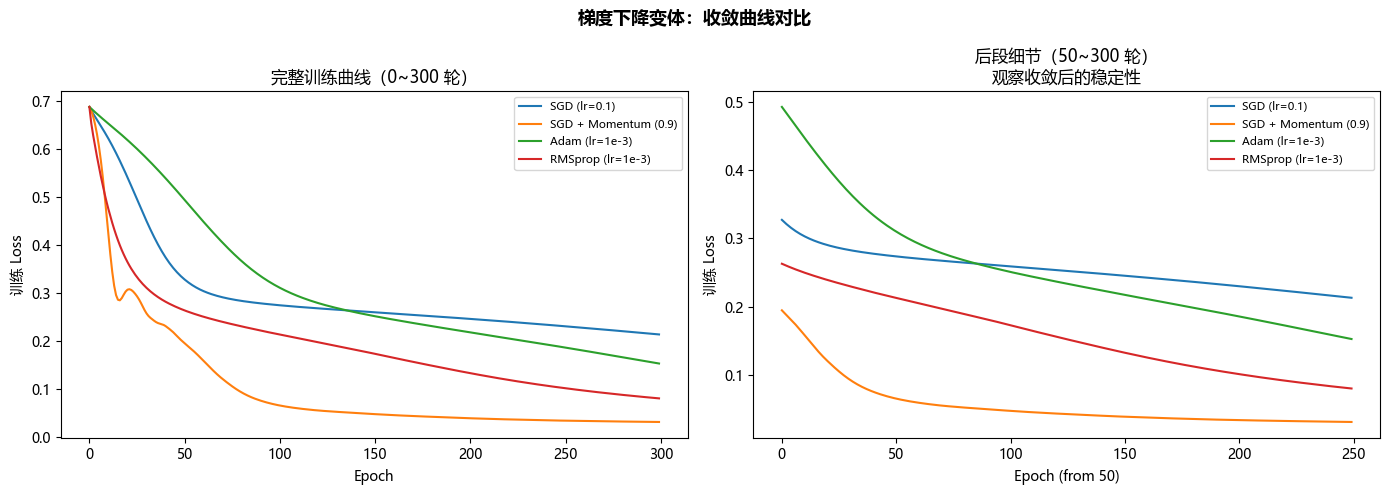


优化器最终 Loss（300 轮）：
  SGD (lr=0.1)                   0.2128
  SGD + Momentum (0.9)           0.0304
  Adam (lr=1e-3)                 0.1522
  RMSprop (lr=1e-3)              0.0796

观察：
  SGD 收敛最慢，需要较长时间才能稳定
  加上 Momentum 后 SGD 明显加速，惯性项帮助跨越小凹陷
  Adam 和 RMSprop 自适应学习率，前期收敛最快
  Adam 综合表现最好 → 实践中的默认首选


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

# ── 数据准备 ────────────────────────────────────────────────────
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr_t = torch.FloatTensor(X_tr)
y_tr_t  = torch.FloatTensor(y_tr)
X_te_t  = torch.FloatTensor(X_te)
y_te_t  = torch.FloatTensor(y_te)

# ── 演示 1：前向传播 + 反向传播手动追踪 ────────────────────────
print("=== 前向传播 + 反向传播：手动追踪 ===")
print()

class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)
    def forward(self, x):
        h = torch.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(h)).squeeze()

net = TinyNet()
loss_fn = nn.BCELoss()

# 取一个 batch
xb = X_tr_t[:8]
yb = y_tr_t[:8]

print(f"输入形状：{xb.shape}   标签形状：{yb.shape}")

# 前向传播
pred = net(xb)
loss = loss_fn(pred, yb)
print(f"\n前向传播完成")
print(f"  预测值（前 4 个）: {pred.detach().numpy()[:4].round(4)}")
print(f"  真实标签（前 4 个）: {yb.numpy()[:4].astype(int)}")
print(f"  损失值 (BCE Loss): {loss.item():.4f}")

# 反向传播前，梯度为 None
print(f"\n反向传播前，fc1.weight.grad: {net.fc1.weight.grad}")

# 反向传播
loss.backward()
print(f"反向传播后，fc1.weight.grad 形状: {net.fc1.weight.grad.shape}")
print(f"  梯度样例（第1行）: {net.fc1.weight.grad[0].detach().numpy().round(5)}")
print(f"  → PyTorch 自动通过计算图反向计算了所有层的梯度")

# ── 演示 2：不同优化器的收敛曲线对比 ───────────────────────────
print("\n=== 优化器收敛速度对比 ===")

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

def run_optimizer(opt_cls, opt_kwargs, epochs=300):
    torch.manual_seed(0)
    model = Net()
    optimizer = opt_cls(model.parameters(), **opt_kwargs)
    loss_fn   = nn.BCELoss()
    losses = []
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_tr_t), y_tr_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

optimizer_configs = [
    ('SGD (lr=0.1)',           optim.SGD,     {'lr': 0.1}),
    ('SGD + Momentum (0.9)',   optim.SGD,     {'lr': 0.1, 'momentum': 0.9}),
    ('Adam (lr=1e-3)',         optim.Adam,    {'lr': 1e-3}),
    ('RMSprop (lr=1e-3)',      optim.RMSprop, {'lr': 1e-3}),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('梯度下降变体：收敛曲线对比', fontsize=13, fontweight='bold')

all_losses = {}
for name, cls, kwargs in optimizer_configs:
    losses = run_optimizer(cls, kwargs)
    all_losses[name] = losses
    axes[0].plot(losses, label=name, lw=1.5)
    axes[1].plot(losses[50:], label=name, lw=1.5)  # 放大后半段

axes[0].set_title('完整训练曲线（0~300 轮）')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('训练 Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('后段细节（50~300 轮）\n观察收敛后的稳定性')
axes[1].set_xlabel('Epoch (from 50)')
axes[1].set_ylabel('训练 Loss')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n优化器最终 Loss（300 轮）：")
for name, losses in all_losses.items():
    print(f"  {name:<30} {losses[-1]:.4f}")
print()
print("观察：")
print("  SGD 收敛最慢，需要较长时间才能稳定")
print("  加上 Momentum 后 SGD 明显加速，惯性项帮助跨越小凹陷")
print("  Adam 和 RMSprop 自适应学习率，前期收敛最快")
print("  Adam 综合表现最好 → 实践中的默认首选")

## 3.3 正则化与调参

深度学习模型容量很大，在训练集上容易过拟合。正则化技术的目标是：**在不减少模型容量的前提下，降低模型对训练集噪声的记忆**。

---

### Dropout

训练时随机将部分神经元的输出置为 0（即「丢弃」），使网络不能依赖任何单一特征或神经元，被迫学习更鲁棒的表示。

```
训练时：每个神经元以概率 p 被丢弃 → 每次 forward 看到一个略不同的网络
预测时：所有神经元都保留，但输出乘以 (1-p) 保持期望值不变
```

**为什么有效？** 可以理解为训练了指数级数量的「瘦子网络」并做了隐式集成。

- `p=0.5`：隐藏层常用
- `p=0.1~0.3`：输入层或卷积层，丢弃率不宜过高
- 如果验证集 Loss 和训练集 Loss 差距大（过拟合），增大 dropout rate；如果模型欠拟合，减小或去掉 Dropout

---

### Batch Normalization（BatchNorm）

在每一层的激活值上做标准化：对当前 batch 内，把每个特征维度的输出归一化到均值 0、方差 1，然后用可学习的参数 $\gamma, \beta$ 恢复表达能力。

$$\hat{x} = \frac{x - \mu_{batch}}{\sqrt{\sigma^2_{batch} + \epsilon}} \qquad y = \gamma \hat{x} + \beta$$

**效果**：
- 大幅加速训练（允许使用更大的学习率）
- 减少对权重初始化的敏感性
- 有轻微正则化效果（batch 内的随机性引入噪声）

**放置位置**：通常放在线性层/卷积层之后、激活函数之前（`Linear → BN → ReLU`）。

> **注意**：BatchNorm 在训练和推理时行为不同——训练时用当前 batch 的统计量，推理时用训练阶段积累的移动平均。必须在推理时调用 `model.eval()`，否则统计量不对。

---

### 学习率调度（Learning Rate Scheduling）

固定学习率的问题：
- 太大：在极值附近震荡，无法收敛
- 太小：收敛过慢，容易陷入局部最优

解决方案：**从大到小动态调整学习率**。

| 调度策略 | 规律 | 适用场景 |
|---------|------|----------|
| **StepLR** | 每隔 N 轮乘以 γ（如 0.1）| 简单，可预测 |
| **CosineAnnealing** | 余弦曲线衰减，周期性 warm restart | 图像识别常用 |
| **ReduceLROnPlateau** | 验证集 Loss 停滞时自动降低 | 不确定何时衰减时首选 |
| **Warmup + Decay** | 先线性升温再衰减 | Transformer 标配 |

---

### 早停（Early Stopping）

训练时监控**验证集 Loss**，当验证 Loss 停止下降超过 N 轮（patience）时停止训练，保存此前验证 Loss 最低的模型。

```
          训练 Loss ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓（一直在下降）
          验证 Loss ↓↓↓↓↓（开始上升）↑↑↑↑↑ ← 过拟合开始
                          ↑
                    最佳模型保存点
```

早停是**最简单也最有效**的防过拟合策略之一，可以和其他正则化方法叠加使用。

训练中...


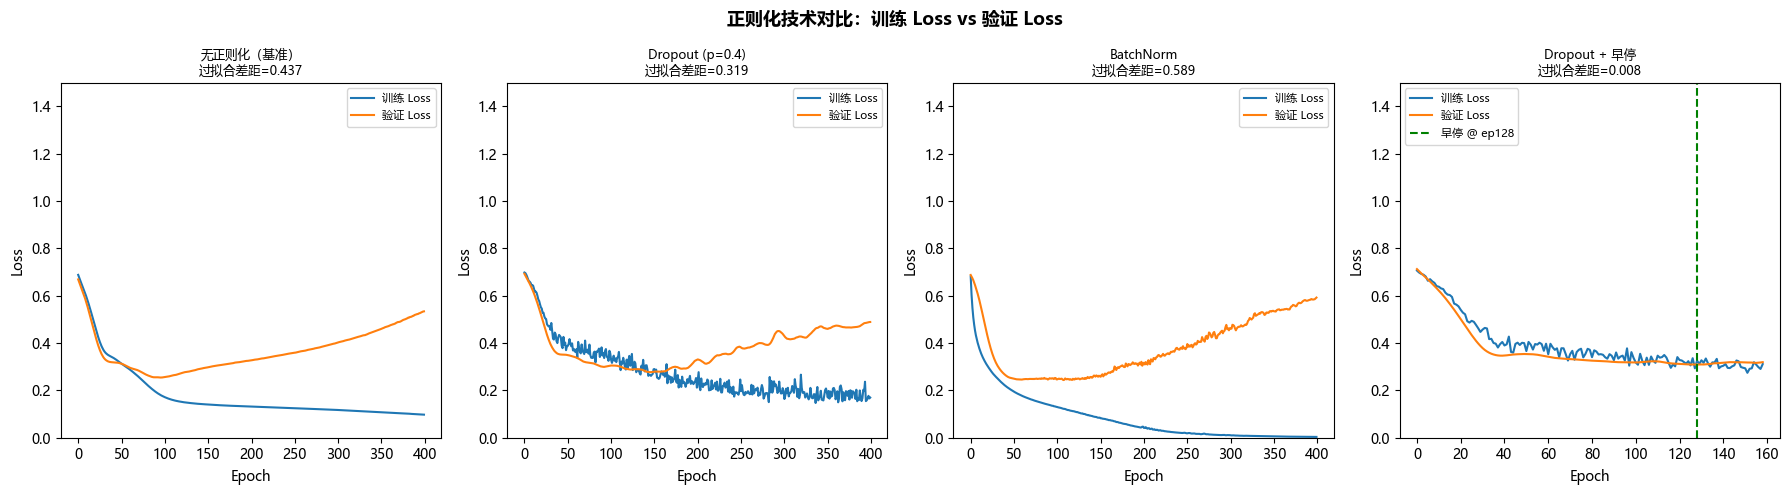


=== 学习率调度演示 ===


C:\Users\I552307\AppData\Local\Temp\claude\ipykernel_38644\4104983583.py:131: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


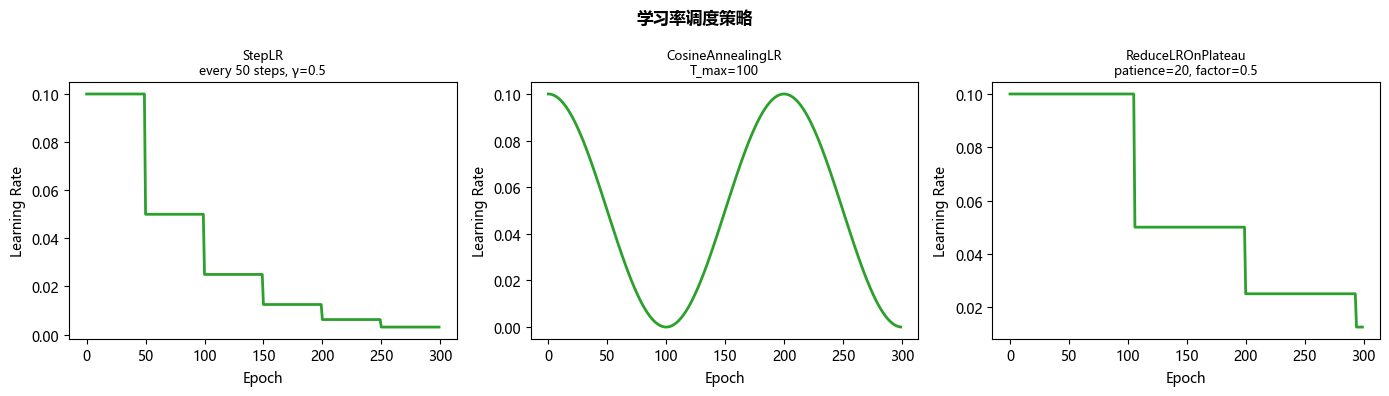


正则化技术总结：
  Dropout  ：训练时随机丢弃神经元，强迫网络学鲁棒表示，相当于隐式集成
  BatchNorm：归一化激活值，加速训练，减少初始化敏感性
  学习率调度：从大到小动态调整，既快速收敛又能精细调整到低 Loss
  早停     ：监控验证集 Loss，在过拟合发生前停止，最简单有效的方法

实践建议：先加 BatchNorm，再加 Dropout，最后用 ReduceLROnPlateau + 早停


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

# ── 数据（有意用小数据集，更容易展示过拟合）─────────────────
X, y = make_moons(n_samples=200, noise=0.3, random_state=42)
X = StandardScaler().fit_transform(X)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

to_t = lambda arr: torch.FloatTensor(arr)
X_tr_t,  y_tr_t  = to_t(X_tr),  to_t(y_tr)
X_val_t, y_val_t = to_t(X_val), to_t(y_val)

# ── 模型工厂：支持 Dropout 和 BatchNorm 开关 ──────────────────
def make_model(use_dropout=False, use_bn=False, p=0.5):
    layers = []
    dims = [2, 64, 64, 64, 1]
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims) - 2:  # 非最后一层
            if use_bn:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            if use_dropout:
                layers.append(nn.Dropout(p))
        else:
            layers.append(nn.Sigmoid())
    return nn.Sequential(*layers)

def train_and_record(model, epochs=300, lr=1e-3, patience=None):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.BCELoss()
    train_losses, val_losses = [], []
    best_val, best_ep, best_state = float('inf'), 0, None
    no_improve = 0

    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_tr_t).squeeze(), y_tr_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t).squeeze(), y_val_t).item()
        val_losses.append(val_loss)

        # 早停逻辑
        if patience is not None:
            if val_loss < best_val:
                best_val   = val_loss
                best_ep    = ep
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break

    return train_losses, val_losses, best_ep

# ── 4 种配置对比 ───────────────────────────────────────────────
configs = [
    ('无正则化（基准）',   make_model(),                    False),
    ('Dropout (p=0.4)',    make_model(use_dropout=True, p=0.4), False),
    ('BatchNorm',          make_model(use_bn=True),         False),
    ('Dropout + 早停',     make_model(use_dropout=True, p=0.4), True),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('正则化技术对比：训练 Loss vs 验证 Loss', fontsize=13, fontweight='bold')

torch.manual_seed(0)
print("训练中...")
for i, (name, model, use_early_stop) in enumerate(configs):
    torch.manual_seed(0)
    patience_val = 30 if use_early_stop else None
    tr_l, val_l, best_ep = train_and_record(model, epochs=400, patience=patience_val)
    ax = axes[i]
    ax.plot(tr_l,  label='训练 Loss', color='C0', lw=1.5)
    ax.plot(val_l, label='验证 Loss', color='C1', lw=1.5)
    if use_early_stop:
        ax.axvline(best_ep, color='green', linestyle='--', lw=1.5, label=f'早停 @ ep{best_ep}')
    gap = val_l[-1] - tr_l[-1]
    ax.set_title(f'{name}\n过拟合差距={gap:.3f}', fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.show()

# ── 学习率调度演示 ──────────────────────────────────────────────
print("\n=== 学习率调度演示 ===")

fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
fig2.suptitle('学习率调度策略', fontsize=12, fontweight='bold')

schedulers_cfg = [
    ('StepLR\nevery 50 steps, γ=0.5',
     lambda opt: optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.5)),
    ('CosineAnnealingLR\nT_max=100',
     lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)),
    ('ReduceLROnPlateau\npatience=20, factor=0.5',
     lambda opt: optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5)),
]

for ax, (title, sched_fn) in zip(axes2, schedulers_cfg):
    dummy_model = nn.Linear(1, 1)
    opt   = optim.SGD(dummy_model.parameters(), lr=0.1)
    sched = sched_fn(opt)
    lrs   = []
    # 模拟 300 轮，ReduceLROnPlateau 需要传入一个 metric
    fake_loss = np.linspace(1.0, 0.2, 300) + 0.05 * np.sin(np.linspace(0, 20, 300))
    for ep in range(300):
        lrs.append(opt.param_groups[0]['lr'])
        if isinstance(sched, optim.lr_scheduler.ReduceLROnPlateau):
            sched.step(fake_loss[ep])
        else:
            sched.step()
    ax.plot(lrs, color='C2', lw=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')

plt.tight_layout()
plt.show()

print("\n正则化技术总结：")
print("  Dropout  ：训练时随机丢弃神经元，强迫网络学鲁棒表示，相当于隐式集成")
print("  BatchNorm：归一化激活值，加速训练，减少初始化敏感性")
print("  学习率调度：从大到小动态调整，既快速收敛又能精细调整到低 Loss")
print("  早停     ：监控验证集 Loss，在过拟合发生前停止，最简单有效的方法")
print()
print("实践建议：先加 BatchNorm，再加 Dropout，最后用 ReduceLROnPlateau + 早停")